# 中国银行 (601988.SH) 技术指标分析

**数据来源**: Tushare Pro | **复权方式**: 前复权 | **时间范围**: 2021-07-05 ~ 2026-07-03

本 notebook 计算并可视化五个常用技术指标：**RSI、MACD、布林带、ATR、KDJ**。

> 注：遵循中国 A 股惯例，**红色 = 涨，绿色 = 跌**。

## 1. 数据加载与预处理

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# ── 全局样式 ──
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = '#1e1e2e'
plt.rcParams['axes.facecolor'] = '#1e1e2e'
plt.rcParams['axes.edgecolor'] = '#6c7086'
plt.rcParams['axes.labelcolor'] = '#cdd6f4'
plt.rcParams['xtick.color'] = '#cdd6f4'
plt.rcParams['ytick.color'] = '#cdd6f4'
plt.rcParams['text.color'] = '#cdd6f4'
plt.rcParams['grid.color'] = '#45475a'
plt.rcParams['grid.alpha'] = 0.4

# A 股惯例: 红=涨, 绿=跌
RED = '#f38ba8'
GREEN = '#a6e3a1'
BLUE = '#89b4fa'
ORANGE = '#fab387'
PURPLE = '#cba6f7'
YELLOW = '#f9e2af'

# ── 加载前复权数据 ──
DATA_PATH = Path('../data/processed/boc_daily_adj.csv')
df = pd.read_csv(DATA_PATH, encoding='utf-8-sig')

# 日期处理: YYYYMMDD -> datetime
df['date'] = pd.to_datetime(df['trade_date'], format='%Y%m%d')
df = df.sort_values('date').reset_index(drop=True)

# 选用前复权价格 (技术分析标准方案)
df['open']   = df['fwd_open']
df['high']   = df['fwd_high']
df['low']    = df['fwd_low']
df['close']  = df['fwd_close']
df['volume'] = df['vol']

print(f"数据范围: {df['date'].iloc[0].date()} ~ {df['date'].iloc[-1].date()}")
print(f"总交易日: {len(df)}")
print(f"最新收盘: {df['close'].iloc[-1]:.2f}")
df[['date','open','high','low','close','volume']].tail(5)

数据范围: 2021-07-05 ~ 2026-07-03
总交易日: 1211
最新收盘: 5.56


,date,open,high,low,close,volume
1206,2026-06-29,5.75,5.82,5.62,5.80,3291220.40
1207,2026-06-30,5.76,5.78,5.57,5.72,4005578.90
1208,2026-07-01,5.67,5.72,5.64,5.65,2007286.42
1209,2026-07-02,5.66,5.75,5.53,5.58,2935500.41
1210,2026-07-03,5.58,5.63,5.51,5.56,2431256.33


## 2. RSI — 相对强弱指标 (Relative Strength Index)

**含义**: 衡量价格变动的速度和幅度，判断超买/超卖状态。

**公式**:
- 计算 N 日内上涨幅度均值 `avg_gain` 和下跌幅度均值 `avg_loss`
- $RS = \frac{avg\_gain}{avg\_loss}$
- $RSI = 100 - \frac{100}{1 + RS}$

**参数**: 常用 N=14（短期 6/12，长期 24）

**判断标准**:
- RSI > 70 → **超买**（可能回调）
- RSI < 30 → **超卖**（可能反弹）
- RSI ≈ 50 → 多空平衡

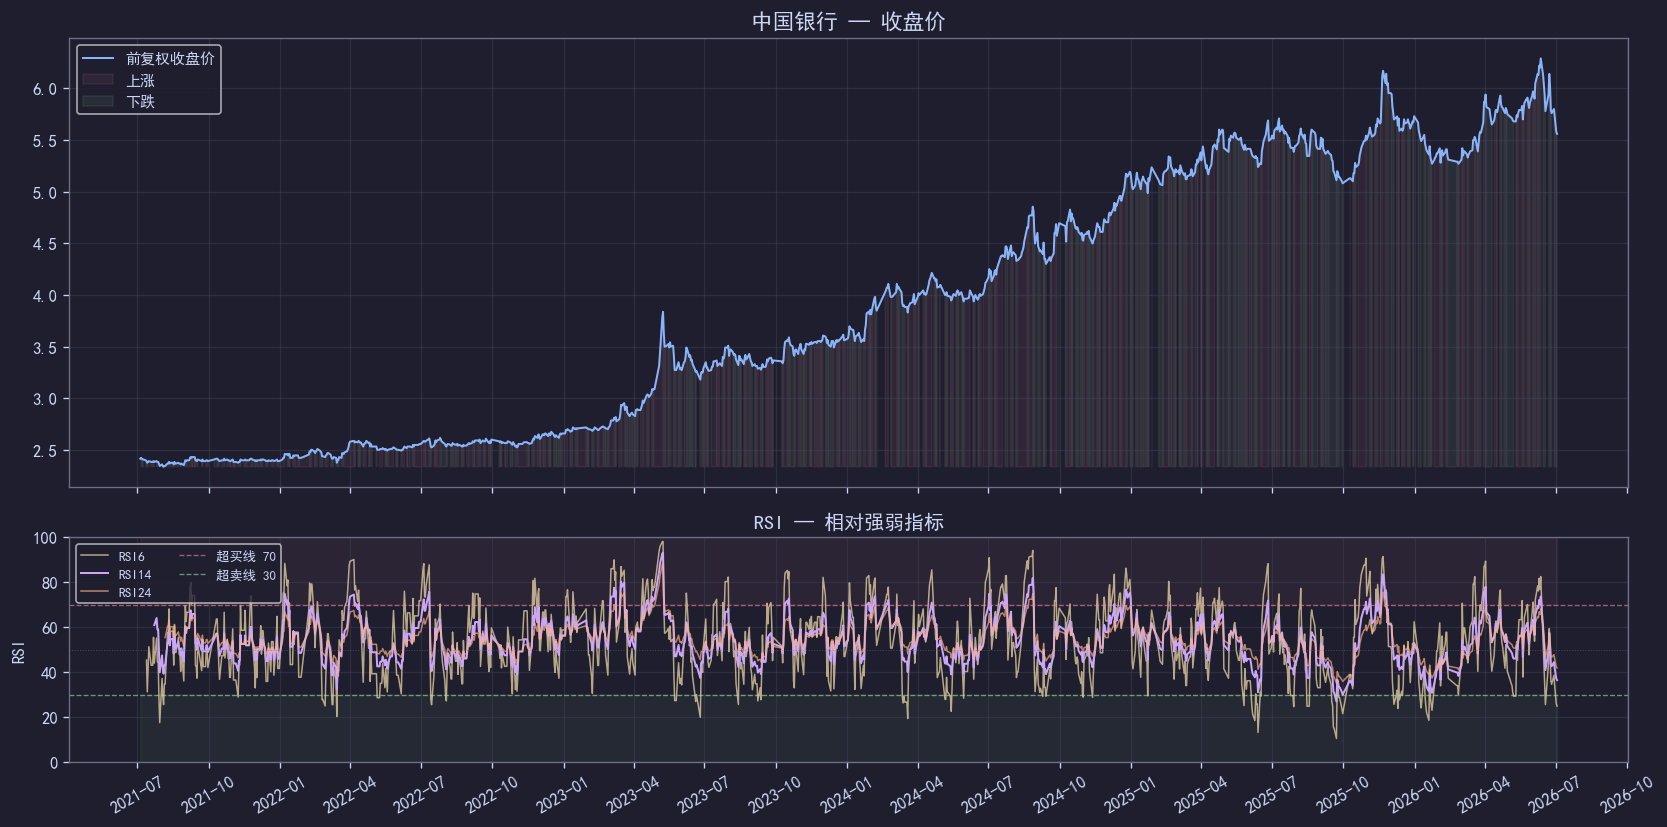

RSI14 最新值: 36.4 → 中性


In [5]:
def calc_rsi(close, period=14):
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    # Wilder 平滑法 (指数移动平均)
    avg_gain = gain.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df['RSI_6']  = calc_rsi(df['close'], 6)
df['RSI_14'] = calc_rsi(df['close'], 14)
df['RSI_24'] = calc_rsi(df['close'], 24)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                          gridspec_kw={'height_ratios': [2, 1]})

# 上图: 收盘价
axes[0].plot(df['date'], df['close'], color=BLUE, linewidth=1.2, label='前复权收盘价')
axes[0].fill_between(df['date'], df['close'].min(), df['close'],
                      where=df['close'].diff() >= 0, alpha=0.08, color=RED, label='上涨')
axes[0].fill_between(df['date'], df['close'].min(), df['close'],
                      where=df['close'].diff() < 0, alpha=0.08, color=GREEN, label='下跌')
axes[0].set_title('中国银行 — 收盘价', fontsize=13, fontweight='bold')
axes[0].legend(loc='upper left', fontsize=9)
axes[0].grid(True)

# 下图: RSI
axes[1].plot(df['date'], df['RSI_6'],  color=YELLOW,  linewidth=0.9, alpha=0.7, label='RSI6')
axes[1].plot(df['date'], df['RSI_14'], color=PURPLE,  linewidth=1.2, label='RSI14')
axes[1].plot(df['date'], df['RSI_24'], color=ORANGE,  linewidth=0.9, alpha=0.7, label='RSI24')
axes[1].axhline(70, color=RED,   linestyle='--', linewidth=0.8, alpha=0.6, label='超买线 70')
axes[1].axhline(50, color='#6c7086', linestyle=':', linewidth=0.6, alpha=0.5)
axes[1].axhline(30, color=GREEN, linestyle='--', linewidth=0.8, alpha=0.6, label='超卖线 30')
axes[1].fill_between(df['date'], 70, 100, alpha=0.06, color=RED)
axes[1].fill_between(df['date'], 0, 30,  alpha=0.06, color=GREEN)
axes[1].set_title('RSI — 相对强弱指标', fontsize=12, fontweight='bold')
axes[1].set_ylabel('RSI')
axes[1].set_ylim(0, 100)
axes[1].legend(loc='upper left', fontsize=8, ncol=2)
axes[1].grid(True)

axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../outputs/boc_rsi.png', dpi=150, bbox_inches='tight', facecolor='#1e1e2e')
plt.show()
print(f"RSI14 最新值: {df['RSI_14'].iloc[-1]:.1f}", "→ 超买" if df['RSI_14'].iloc[-1] > 70 else "→ 超卖" if df['RSI_14'].iloc[-1] < 30 else "→ 中性")

## 3. MACD — 指数平滑移动平均线 (Moving Average Convergence Divergence)

**含义**: 通过快慢均线之差判断趋势方向和动量强弱。

**公式**:
- $EMA_{fast}$ = 12 日指数移动平均
- $EMA_{slow}$ = 26 日指数移动平均
- $DIF = EMA_{fast} - EMA_{slow}$ （差离值）
- $DEA = EMA_9(DIF)$ （信号线）
- $MACD_{hist} = 2 \times (DIF - DEA)$ （柱状图）

**判断标准**:
- DIF 上穿 DEA → **金叉**（买入信号）
- DIF 下穿 DEA → **死叉**（卖出信号）
- 柱状图由负转正 → 动量转多
- 零轴上方 → 多头市场；零轴下方 → 空头市场

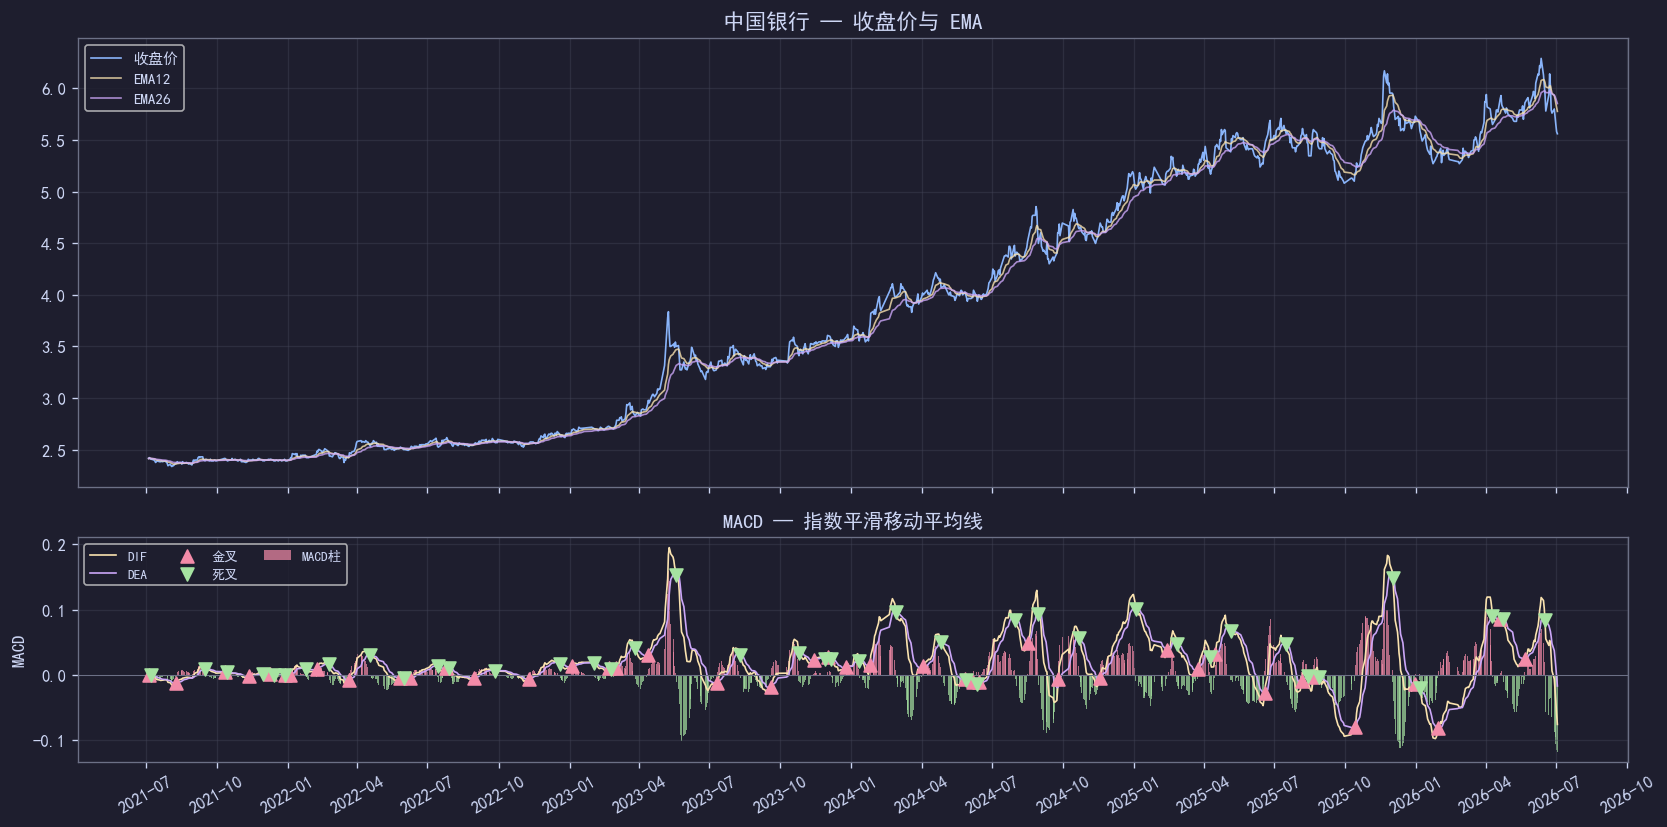

金叉次数: 42 | 死叉次数: 42
DIF 最新: -0.0758 | DEA 最新: -0.0170 | 柱状: -0.1176


In [7]:
def calc_ema(series, period):
    return series.ewm(span=period, adjust=False).mean()

ema12 = calc_ema(df['close'], 12)
ema26 = calc_ema(df['close'], 26)
df['DIF']  = ema12 - ema26
df['DEA']  = calc_ema(df['DIF'], 9)
df['MACD_hist'] = 2 * (df['DIF'] - df['DEA'])

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                          gridspec_kw={'height_ratios': [2, 1]})

# 上图: 收盘价 + EMA
axes[0].plot(df['date'], df['close'], color=BLUE,   linewidth=1.0, label='收盘价')
axes[0].plot(df['date'], ema12,       color=YELLOW, linewidth=1.0, alpha=0.8, label='EMA12')
axes[0].plot(df['date'], ema26,       color=PURPLE, linewidth=1.0, alpha=0.8, label='EMA26')
axes[0].set_title('中国银行 — 收盘价与 EMA', fontsize=13, fontweight='bold')
axes[0].legend(loc='upper left', fontsize=9)
axes[0].grid(True)

# 下图: MACD
colors_hist = [RED if v >= 0 else GREEN for v in df['MACD_hist']]
axes[1].bar(df['date'], df['MACD_hist'], color=colors_hist, width=1.2, alpha=0.7, label='MACD柱')
axes[1].plot(df['date'], df['DIF'], color=YELLOW, linewidth=1.0, label='DIF')
axes[1].plot(df['date'], df['DEA'], color=PURPLE, linewidth=1.0, label='DEA')
axes[1].axhline(0, color='#6c7086', linewidth=0.6)

# 标记金叉/死叉
cross_up   = (df['DIF'] > df['DEA']) & (df['DIF'].shift(1) <= df['DEA'].shift(1))
cross_down = (df['DIF'] < df['DEA']) & (df['DIF'].shift(1) >= df['DEA'].shift(1))
axes[1].scatter(df.loc[cross_up, 'date'],   df.loc[cross_up, 'DIF'],   marker='^', s=60, color=RED,   zorder=5, label='金叉')
axes[1].scatter(df.loc[cross_down, 'date'], df.loc[cross_down, 'DIF'], marker='v', s=60, color=GREEN, zorder=5, label='死叉')

axes[1].set_title('MACD — 指数平滑移动平均线', fontsize=12, fontweight='bold')
axes[1].set_ylabel('MACD')
axes[1].legend(loc='upper left', fontsize=8, ncol=3)
axes[1].grid(True)

axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../outputs/boc_macd.png', dpi=150, bbox_inches='tight', facecolor='#1e1e2e')
plt.show()

n_gold = cross_up.sum()
n_dead = cross_down.sum()
print(f"金叉次数: {n_gold} | 死叉次数: {n_dead}")
print(f"DIF 最新: {df['DIF'].iloc[-1]:.4f} | DEA 最新: {df['DEA'].iloc[-1]:.4f} | 柱状: {df['MACD_hist'].iloc[-1]:.4f}")

## 4. BOLL — 布林带 (Bollinger Bands)

**含义**: 用统计方法衡量价格波动的上下限，判断相对高低和波动率。

**公式**:
- $MID = MA(close, 20)$ （中轨，20 日均线）
- $UPPER = MID + 2\sigma$ （上轨）
- $LOWER = MID - 2\sigma$ （下轨）
- $\sigma$ = 20 日收盘价标准差

**判断标准**:
- 价格触及/突破上轨 → **超买**（可能回调）
- 价格触及/突破下轨 → **超卖**（可能反弹）
- 带宽收窄 → 波动率低，可能酝酿大行情
- 带宽扩张 → 波动率高，趋势加速

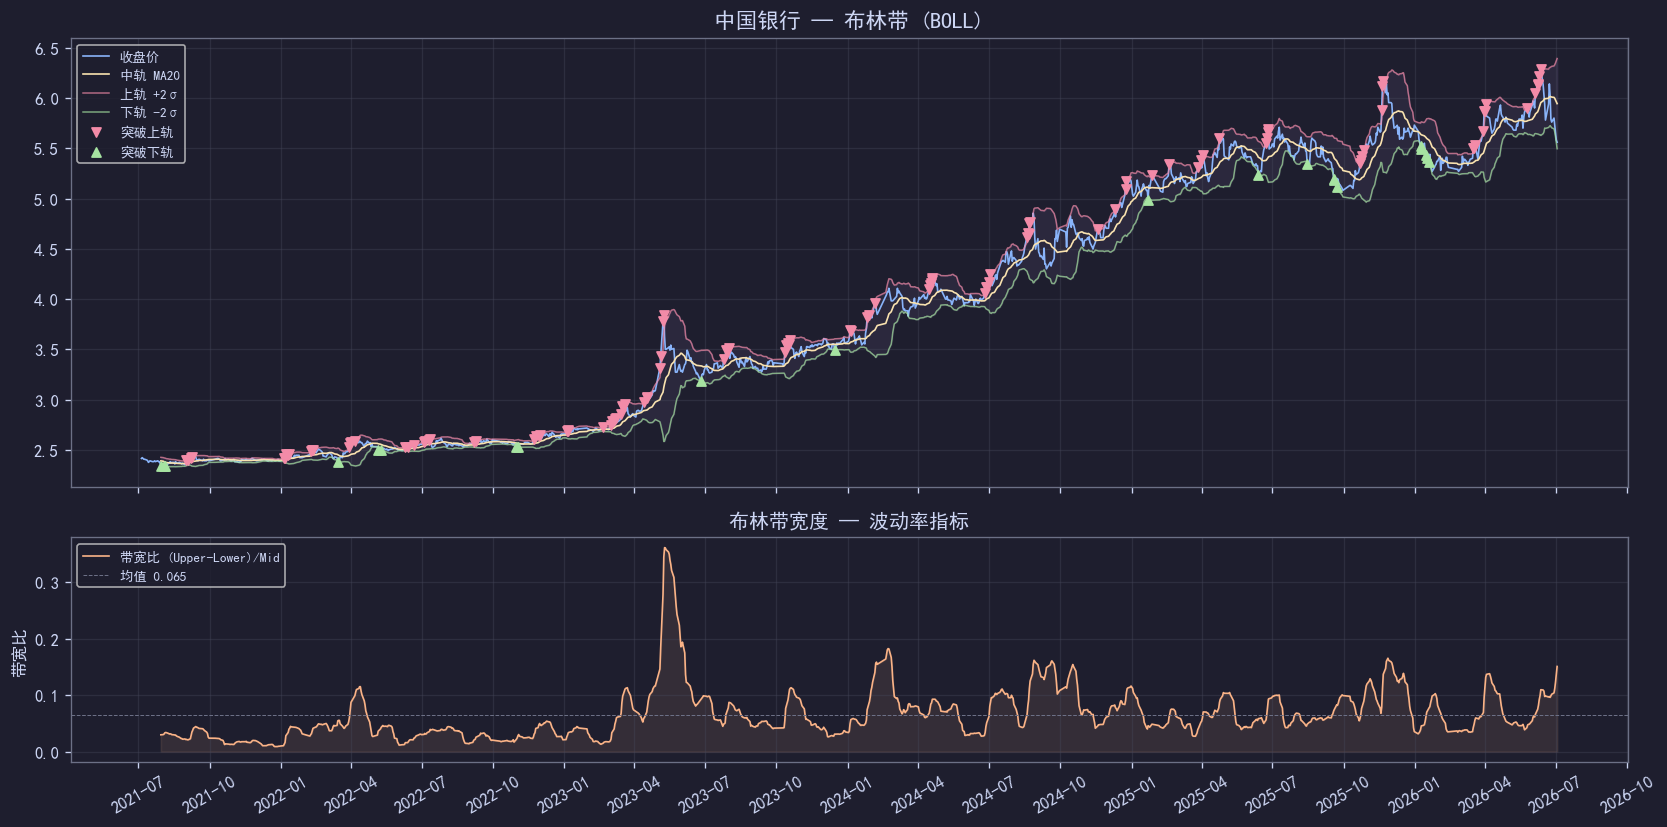

上轨: 6.39 | 中轨: 5.94 | 下轨: 5.50
%B: 0.07 → 接近下轨


In [9]:
window = 20
df['BOLL_MID']   = df['close'].rolling(window).mean()
std = df['close'].rolling(window).std()
df['BOLL_UPPER'] = df['BOLL_MID'] + 2 * std
df['BOLL_LOWER'] = df['BOLL_MID'] - 2 * std
df['BOLL_WIDTH'] = (df['BOLL_UPPER'] - df['BOLL_LOWER']) / df['BOLL_MID']  # 带宽比
df['BOLL_PCTB']  = (df['close'] - df['BOLL_LOWER']) / (df['BOLL_UPPER'] - df['BOLL_LOWER'])  # %B

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                          gridspec_kw={'height_ratios': [2, 1]})

# 上图: 布林带
axes[0].plot(df['date'], df['close'],      color=BLUE,   linewidth=1.0, label='收盘价')
axes[0].plot(df['date'], df['BOLL_MID'],   color=YELLOW, linewidth=1.0, label='中轨 MA20')
axes[0].plot(df['date'], df['BOLL_UPPER'], color=RED,    linewidth=0.9, alpha=0.7, label='上轨 +2σ')
axes[0].plot(df['date'], df['BOLL_LOWER'], color=GREEN,  linewidth=0.9, alpha=0.7, label='下轨 -2σ')
axes[0].fill_between(df['date'], df['BOLL_LOWER'], df['BOLL_UPPER'], alpha=0.08, color=PURPLE)

# 标记突破上/下轨
break_up   = df['close'] > df['BOLL_UPPER']
break_down = df['close'] < df['BOLL_LOWER']
axes[0].scatter(df.loc[break_up, 'date'],   df.loc[break_up, 'close'],   marker='v', s=30, color=RED,   zorder=5, label='突破上轨')
axes[0].scatter(df.loc[break_down, 'date'], df.loc[break_down, 'close'], marker='^', s=30, color=GREEN, zorder=5, label='突破下轨')

axes[0].set_title('中国银行 — 布林带 (BOLL)', fontsize=13, fontweight='bold')
axes[0].legend(loc='upper left', fontsize=8)
axes[0].grid(True)

# 下图: 带宽
axes[1].plot(df['date'], df['BOLL_WIDTH'], color=ORANGE, linewidth=1.0, label='带宽比 (Upper-Lower)/Mid')
axes[1].axhline(df['BOLL_WIDTH'].mean(), color='#6c7086', linestyle='--', linewidth=0.6, label=f"均值 {df['BOLL_WIDTH'].mean():.3f}")
axes[1].fill_between(df['date'], 0, df['BOLL_WIDTH'], alpha=0.1, color=ORANGE)
axes[1].set_title('布林带宽度 — 波动率指标', fontsize=12, fontweight='bold')
axes[1].set_ylabel('带宽比')
axes[1].legend(loc='upper left', fontsize=8)
axes[1].grid(True)

axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../outputs/boc_boll.png', dpi=150, bbox_inches='tight', facecolor='#1e1e2e')
plt.show()
print(f"上轨: {df['BOLL_UPPER'].iloc[-1]:.2f} | 中轨: {df['BOLL_MID'].iloc[-1]:.2f} | 下轨: {df['BOLL_LOWER'].iloc[-1]:.2f}")
print(f"%B: {df['BOLL_PCTB'].iloc[-1]:.2f}", "→ 接近上轨" if df['BOLL_PCTB'].iloc[-1] > 0.8 else "→ 接近下轨" if df['BOLL_PCTB'].iloc[-1] < 0.2 else "→ 中间区域")

## 5. ATR — 真实波幅 (Average True Range)

**含义**: 衡量价格波动的绝对幅度，常用于止损设置和仓位管理。

**公式**:
- $TR = \max(High - Low,\ |High - PreClose|,\ |Low - PreClose|)$
- $ATR = EMA_{14}(TR)$ （Wilder 平滑法）

**应用场景**:
- ATR 越大 → 波动越剧烈，风险越高
- 常用于动态止损：$StopLoss = EntryPrice - n \times ATR$
- ATR 上升 → 市场波动加剧；ATR 下降 → 市场趋于平静
- 不指示方向，只衡量波动幅度

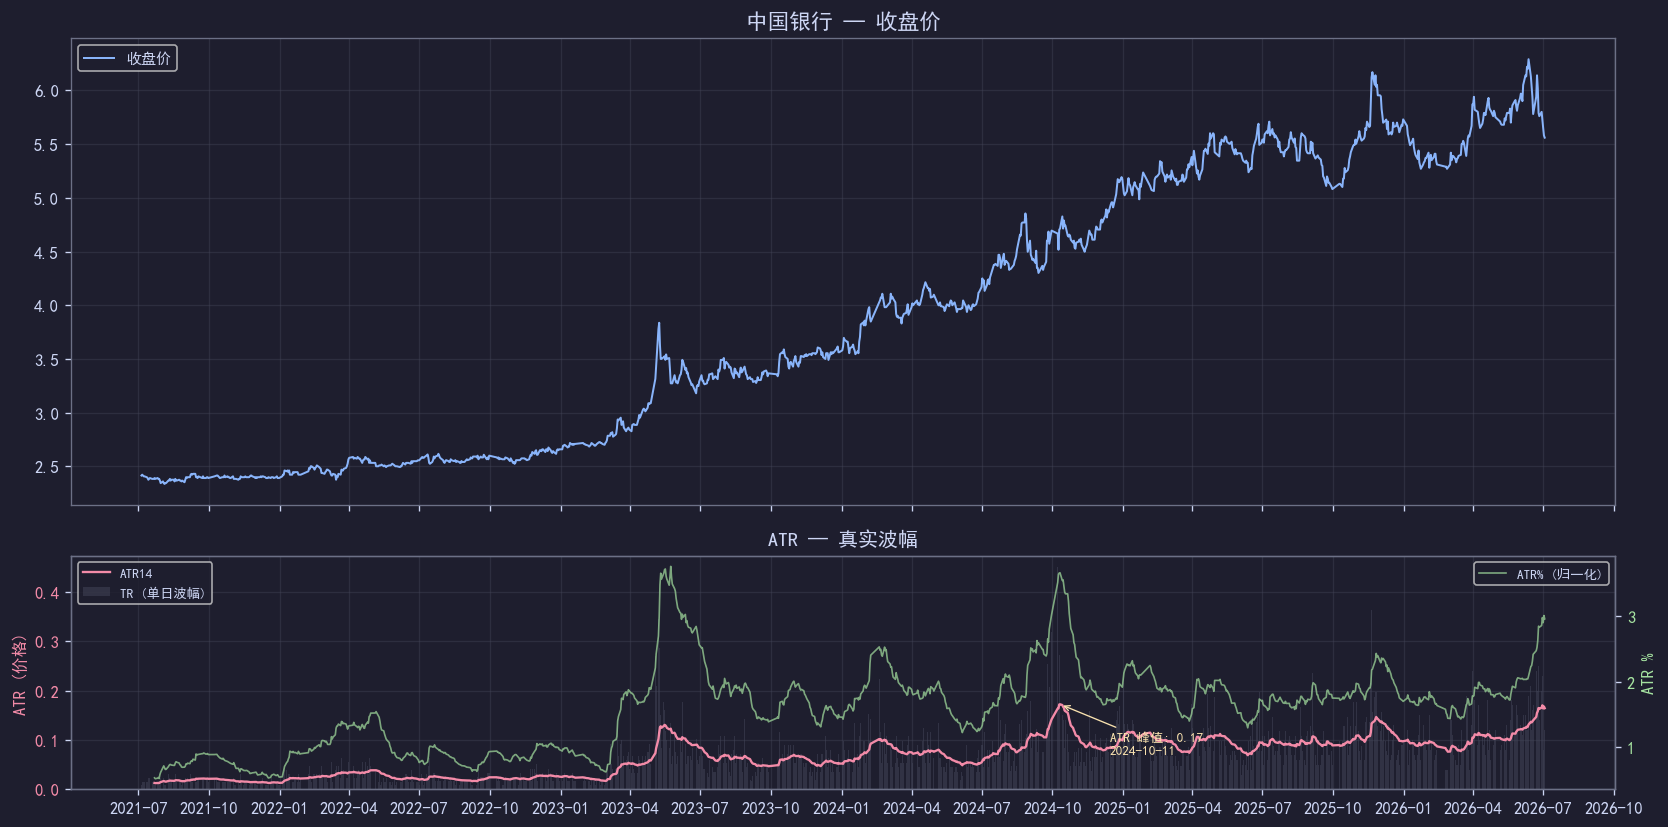

ATR 最新: 0.164 (2.96%)
ATR 均值: 0.066 | 峰值: 0.172


In [11]:
def calc_atr(high, low, close, period=14):
    prev_close = close.shift(1)
    tr1 = high - low
    tr2 = (high - prev_close).abs()
    tr3 = (low - prev_close).abs()
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    atr = tr.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
    return tr, atr

df['TR'], df['ATR_14'] = calc_atr(df['high'], df['low'], df['close'], 14)

# ATR 百分比 (相对价格的归一化)
df['ATR_PCT'] = df['ATR_14'] / df['close'] * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                          gridspec_kw={'height_ratios': [2, 1]})

# 上图: 收盘价
axes[0].plot(df['date'], df['close'], color=BLUE, linewidth=1.2, label='收盘价')
axes[0].set_title('中国银行 — 收盘价', fontsize=13, fontweight='bold')
axes[0].legend(loc='upper left', fontsize=9)
axes[0].grid(True)

# 下图: ATR
ax2 = axes[1]
ax2.bar(df['date'], df['TR'], color='#45475a', width=1.0, alpha=0.5, label='TR (单日波幅)')
ax2.plot(df['date'], df['ATR_14'], color=RED, linewidth=1.4, label='ATR14')
ax2.set_ylabel('ATR (价格)', color=RED)
ax2.tick_params(axis='y', labelcolor=RED)
ax2.set_title('ATR — 真实波幅', fontsize=12, fontweight='bold')
ax2.legend(loc='upper left', fontsize=8)
ax2.grid(True)

# 右轴: ATR 百分比
ax2r = ax2.twinx()
ax2r.plot(df['date'], df['ATR_PCT'], color=GREEN, linewidth=1.0, alpha=0.7, label='ATR% (归一化)')
ax2r.set_ylabel('ATR %', color=GREEN)
ax2r.tick_params(axis='y', labelcolor=GREEN)
ax2r.legend(loc='upper right', fontsize=8)

# 标注 ATR 峰值
atr_peak_idx = df['ATR_14'].idxmax()
axes[1].annotate(f"ATR 峰值: {df['ATR_14'].iloc[atr_peak_idx]:.2f}\n{df['date'].iloc[atr_peak_idx].date()}",
                  xy=(df['date'].iloc[atr_peak_idx], df['ATR_14'].iloc[atr_peak_idx]),
                  xytext=(30, -30), textcoords='offset points',
                  fontsize=8, color='#f9e2af',
                  arrowprops=dict(color='#f9e2af', arrowstyle='->', lw=0.8))

axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../outputs/boc_atr.png', dpi=150, bbox_inches='tight', facecolor='#1e1e2e')
plt.show()
print(f"ATR 最新: {df['ATR_14'].iloc[-1]:.3f} ({df['ATR_PCT'].iloc[-1]:.2f}%)")
print(f"ATR 均值: {df['ATR_14'].mean():.3f} | 峰值: {df['ATR_14'].max():.3f}")

## 6. KDJ — 随机指标 (Stochastic Oscillator)

**含义**: 通过收盘价在近期价格区间中的位置判断超买超卖和短期转折。

**公式**:
- $RSV = \frac{Close - Low_n}{High_n - Low_n} \times 100$ （n=9 日）
- $K = \frac{2}{3} \times K_{prev} + \frac{1}{3} \times RSV$
- $D = \frac{2}{3} \times D_{prev} + \frac{1}{3} \times K$
- $J = 3K - 2D$

**判断标准**:
- K 上穿 D → **金叉**（买入）
- K 下穿 D → **死叉**（卖出）
- K/D > 80 → 超买
- K/D < 20 → 超卖
- J > 100 或 J < 0 → 极端区域，反转概率高

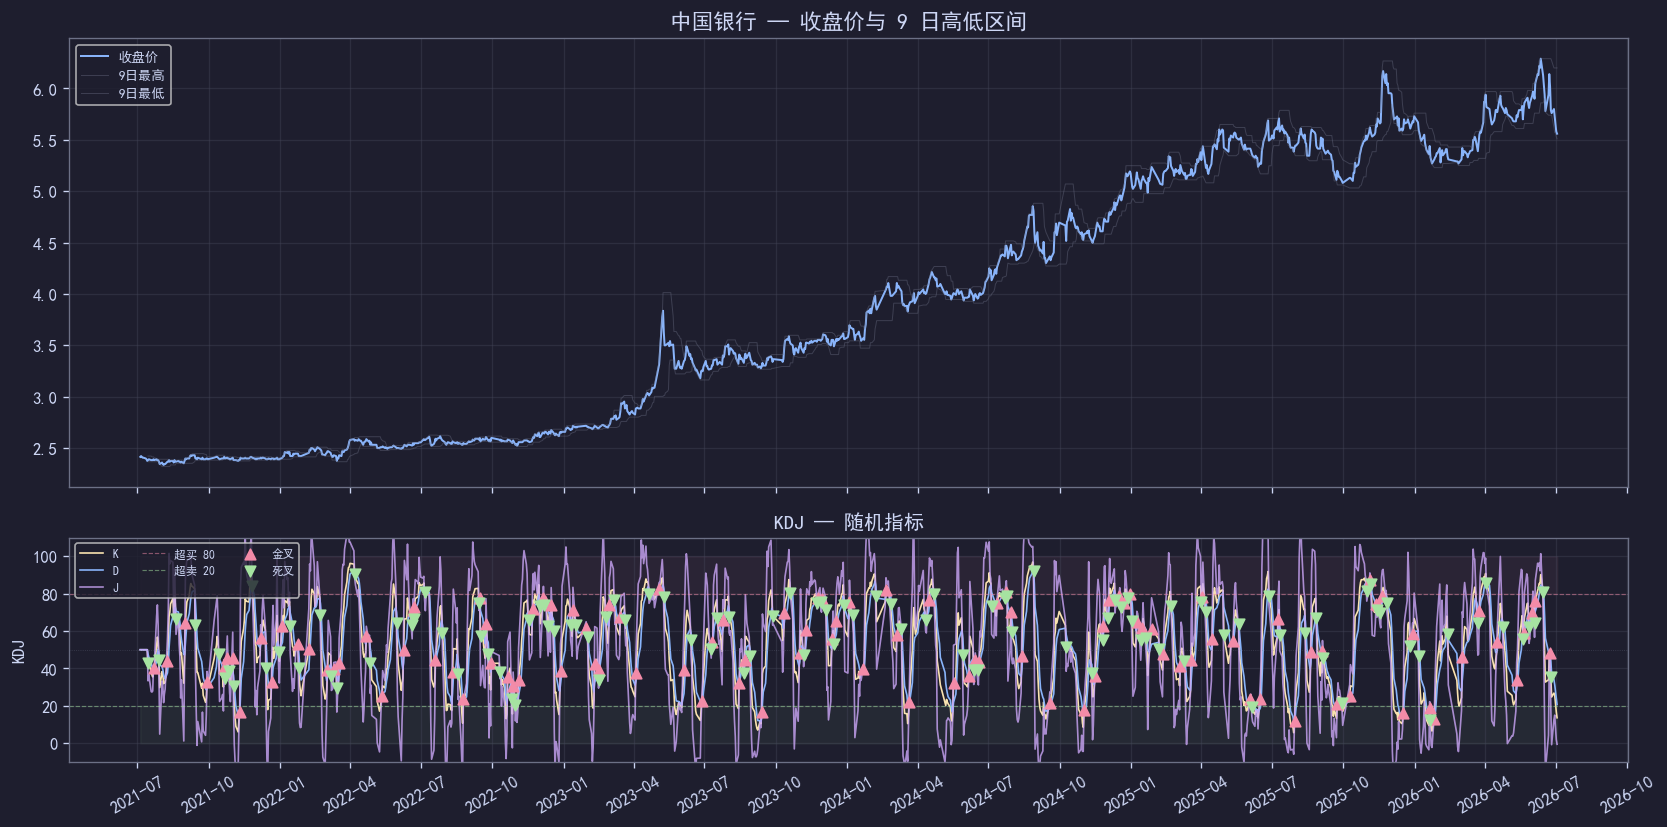

K: 13.6 | D: 20.7 | J: -0.6


In [13]:
def calc_kdj(high, low, close, n=9, m1=3, m2=3):
    low_n  = low.rolling(n).min()
    high_n = high.rolling(n).max()
    rsv = (close - low_n) / (high_n - low_n) * 100
    rsv = rsv.fillna(50)

    k = pd.Series(index=close.index, dtype=float)
    d = pd.Series(index=close.index, dtype=float)
    k.iloc[0] = 50
    d.iloc[0] = 50
    for i in range(1, len(close)):
        k.iloc[i] = (m1 - 1) / m1 * k.iloc[i-1] + 1 / m1 * rsv.iloc[i]
        d.iloc[i] = (m2 - 1) / m2 * d.iloc[i-1] + 1 / m2 * k.iloc[i]
    j = 3 * k - 2 * d
    return k, d, j

df['K'], df['D'], df['J'] = calc_kdj(df['high'], df['low'], df['close'])

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                          gridspec_kw={'height_ratios': [2, 1]})

# 上图: 收盘价
axes[0].plot(df['date'], df['close'], color=BLUE, linewidth=1.2, label='收盘价')
axes[0].plot(df['date'], df['high'].rolling(9).max(), color='#6c7086', linewidth=0.6, alpha=0.4, label='9日最高')
axes[0].plot(df['date'], df['low'].rolling(9).min(),  color='#6c7086', linewidth=0.6, alpha=0.4, label='9日最低')
axes[0].set_title('中国银行 — 收盘价与 9 日高低区间', fontsize=13, fontweight='bold')
axes[0].legend(loc='upper left', fontsize=8)
axes[0].grid(True)

# 下图: KDJ
axes[1].plot(df['date'], df['K'], color=YELLOW, linewidth=1.0, label='K')
axes[1].plot(df['date'], df['D'], color=BLUE,   linewidth=1.0, label='D')
axes[1].plot(df['date'], df['J'], color=PURPLE, linewidth=1.0, alpha=0.8, label='J')
axes[1].axhline(80, color=RED,   linestyle='--', linewidth=0.7, alpha=0.5, label='超买 80')
axes[1].axhline(50, color='#6c7086', linestyle=':', linewidth=0.5, alpha=0.4)
axes[1].axhline(20, color=GREEN, linestyle='--', linewidth=0.7, alpha=0.5, label='超卖 20')
axes[1].fill_between(df['date'], 80, 100, alpha=0.06, color=RED)
axes[1].fill_between(df['date'], 0, 20,  alpha=0.06, color=GREEN)
axes[1].set_ylim(-10, 110)

# 标记金叉死叉
kd_gold = (df['K'] > df['D']) & (df['K'].shift(1) <= df['D'].shift(1))
kd_dead = (df['K'] < df['D']) & (df['K'].shift(1) >= df['D'].shift(1))
axes[1].scatter(df.loc[kd_gold, 'date'], df.loc[kd_gold, 'K'], marker='^', s=40, color=RED,   zorder=5, label='金叉')
axes[1].scatter(df.loc[kd_dead, 'date'], df.loc[kd_dead, 'K'], marker='v', s=40, color=GREEN, zorder=5, label='死叉')

axes[1].set_title('KDJ — 随机指标', fontsize=12, fontweight='bold')
axes[1].set_ylabel('KDJ')
axes[1].legend(loc='upper left', fontsize=7, ncol=3)
axes[1].grid(True)

axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../outputs/boc_kdj.png', dpi=150, bbox_inches='tight', facecolor='#1e1e2e')
plt.show()
print(f"K: {df['K'].iloc[-1]:.1f} | D: {df['D'].iloc[-1]:.1f} | J: {df['J'].iloc[-1]:.1f}")

## 7. 综合仪表盘 — 五指标一览

将五个技术指标整合到一张图中，方便快速判断当前状态。

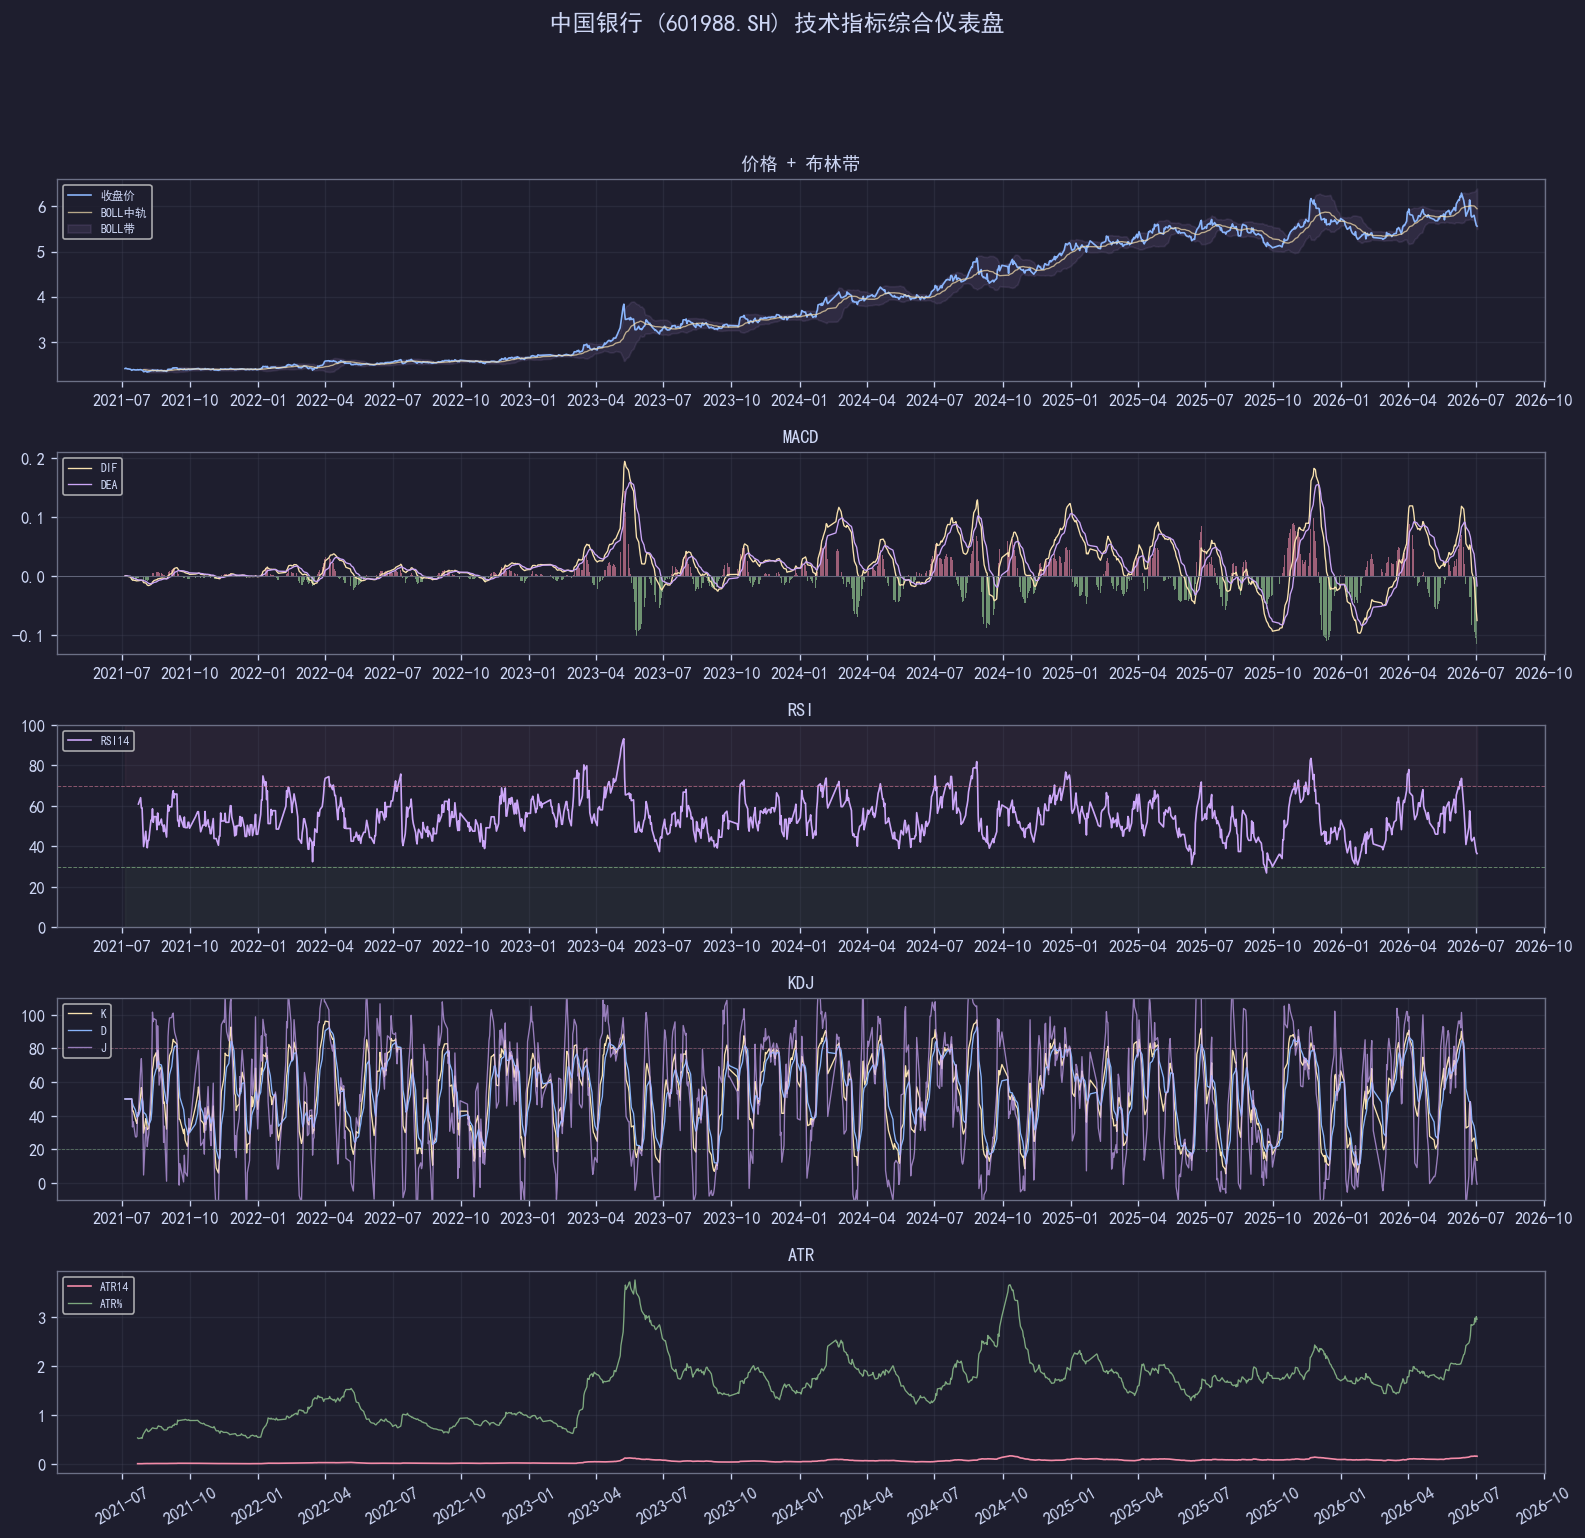

In [15]:
fig = plt.figure(figsize=(16, 14))

# 用 GridSpec 布局
from matplotlib.gridspec import GridSpec
gs = GridSpec(5, 1, hspace=0.35, figure=fig)

# 1. 价格 + 布林带
ax1 = fig.add_subplot(gs[0])
ax1.plot(df['date'], df['close'],      color=BLUE,   linewidth=1.0, label='收盘价')
ax1.plot(df['date'], df['BOLL_MID'],   color=YELLOW, linewidth=0.8, alpha=0.7, label='BOLL中轨')
ax1.fill_between(df['date'], df['BOLL_LOWER'], df['BOLL_UPPER'], alpha=0.1, color=PURPLE, label='BOLL带')
ax1.set_title('价格 + 布林带', fontsize=11, fontweight='bold')
ax1.legend(loc='upper left', fontsize=7)
ax1.grid(True, alpha=0.3)

# 2. MACD
ax2 = fig.add_subplot(gs[1], sharex=ax1)
colors_hist = [RED if v >= 0 else GREEN for v in df['MACD_hist']]
ax2.bar(df['date'], df['MACD_hist'], color=colors_hist, width=1.0, alpha=0.6)
ax2.plot(df['date'], df['DIF'], color=YELLOW, linewidth=0.8, label='DIF')
ax2.plot(df['date'], df['DEA'], color=PURPLE, linewidth=0.8, label='DEA')
ax2.axhline(0, color='#6c7086', linewidth=0.5)
ax2.set_title('MACD', fontsize=11, fontweight='bold')
ax2.legend(loc='upper left', fontsize=7)
ax2.grid(True, alpha=0.3)

# 3. RSI
ax3 = fig.add_subplot(gs[2], sharex=ax1)
ax3.plot(df['date'], df['RSI_14'], color=PURPLE, linewidth=1.0, label='RSI14')
ax3.axhline(70, color=RED,   linestyle='--', linewidth=0.6, alpha=0.5)
ax3.axhline(30, color=GREEN, linestyle='--', linewidth=0.6, alpha=0.5)
ax3.fill_between(df['date'], 70, 100, alpha=0.05, color=RED)
ax3.fill_between(df['date'], 0, 30,  alpha=0.05, color=GREEN)
ax3.set_title('RSI', fontsize=11, fontweight='bold')
ax3.set_ylim(0, 100)
ax3.legend(loc='upper left', fontsize=7)
ax3.grid(True, alpha=0.3)

# 4. KDJ
ax4 = fig.add_subplot(gs[3], sharex=ax1)
ax4.plot(df['date'], df['K'], color=YELLOW, linewidth=0.8, label='K')
ax4.plot(df['date'], df['D'], color=BLUE,   linewidth=0.8, label='D')
ax4.plot(df['date'], df['J'], color=PURPLE, linewidth=0.8, alpha=0.7, label='J')
ax4.axhline(80, color=RED,   linestyle='--', linewidth=0.5, alpha=0.4)
ax4.axhline(20, color=GREEN, linestyle='--', linewidth=0.5, alpha=0.4)
ax4.set_title('KDJ', fontsize=11, fontweight='bold')
ax4.set_ylim(-10, 110)
ax4.legend(loc='upper left', fontsize=7)
ax4.grid(True, alpha=0.3)

# 5. ATR
ax5 = fig.add_subplot(gs[4], sharex=ax1)
ax5.plot(df['date'], df['ATR_14'],  color=RED,   linewidth=1.0, label='ATR14')
ax5.plot(df['date'], df['ATR_PCT'], color=GREEN, linewidth=0.8, alpha=0.7, label='ATR%')
ax5.set_title('ATR', fontsize=11, fontweight='bold')
ax5.legend(loc='upper left', fontsize=7)
ax5.grid(True, alpha=0.3)

ax5.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax5.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=30)
fig.suptitle('中国银行 (601988.SH) 技术指标综合仪表盘', fontsize=14, fontweight='bold', y=0.98)
plt.savefig('../outputs/boc_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#1e1e2e')
plt.show()

## 8. 最新信号汇总

In [17]:
latest = df.iloc[-1]
signals = []

# RSI
rsi_val = latest['RSI_14']
signals.append(('RSI(14)', f"{rsi_val:.1f}", '超买' if rsi_val > 70 else '超卖' if rsi_val < 30 else '中性'))

# MACD
macd_val = latest['MACD_hist']
macd_sig = '多头' if macd_val > 0 else '空头'
# 检查最近金叉/死叉
recent_gold = cross_up.tail(20).any()
recent_dead = cross_down.tail(20).any()
if recent_gold and not recent_dead:
    macd_sig += ' (近期金叉)'
elif recent_dead and not recent_gold:
    macd_sig += ' (近期死叉)'
signals.append(('MACD', f"{macd_val:.4f}", macd_sig))

# BOLL
pctb = latest['BOLL_PCTB']
signals.append(('BOLL %B', f"{pctb:.2f}", '接近上轨' if pctb > 0.8 else '接近下轨' if pctb < 0.2 else '中间区域'))

# ATR
signals.append(('ATR(14)', f"{latest['ATR_14']:.3f}", f"波动率 {latest['ATR_PCT']:.2f}%"))

# KDJ
k_val, d_val, j_val = latest['K'], latest['D'], latest['J']
kd_sig = '超买' if k_val > 80 else '超卖' if k_val < 20 else '中性'
if kd_gold.tail(10).any():
    kd_sig += ' (近期金叉)'
elif kd_dead.tail(10).any():
    kd_sig += ' (近期死叉)'
signals.append(('KDJ', f"K={k_val:.1f} D={d_val:.1f} J={j_val:.1f}", kd_sig))

# 输出表格
print(f"{'指标':<12} {'数值':<28} {'信号':<20}")
print('-' * 62)
for name, val, sig in signals:
    print(f"{name:<12} {val:<28} {sig:<20}")
print('-' * 62)
print(f"数据日期: {latest['date'].date()} | 收盘价: {latest['close']:.2f}")

指标           数值                           信号                  
--------------------------------------------------------------
RSI(14)      36.4                         中性                  
MACD         -0.1176                      空头 (近期死叉)           
BOLL %B      0.07                         接近下轨                
ATR(14)      0.164                        波动率 2.96%           
KDJ          K=13.6 D=20.7 J=-0.6         超卖 (近期金叉)           
--------------------------------------------------------------
数据日期: 2026-07-03 | 收盘价: 5.56


## 9. 指标数据导出

将所有计算得到的技术指标整合导出为 CSV 文件，供后续回测、因子分析或外部工具使用。

In [19]:
# ── 构建指标导出 DataFrame ──
export_cols = [
    'trade_date', 'date',
    'open', 'high', 'low', 'close', 'volume',
    'pct_chg', 'change',
    'RSI_6', 'RSI_14', 'RSI_24',
    'DIF', 'DEA', 'MACD_hist',
    'BOLL_MID', 'BOLL_UPPER', 'BOLL_LOWER', 'BOLL_WIDTH', 'BOLL_PCTB',
    'TR', 'ATR_14', 'ATR_PCT',
    'K', 'D', 'J',
]

export_df = df[export_cols].copy()

# 添加信号标记列
export_df['MACD_golden_cross'] = cross_up.astype(int)
export_df['MACD_death_cross'] = cross_down.astype(int)
export_df['KDJ_golden_cross'] = kd_gold.astype(int)
export_df['KDJ_death_cross'] = kd_dead.astype(int)
export_df['BOLL_break_up'] = break_up.astype(int)
export_df['BOLL_break_down'] = break_down.astype(int)

# RSI 信号
export_df['RSI_oversold'] = (df['RSI_14'] < 30).astype(int)
export_df['RSI_overbought'] = (df['RSI_14'] > 70).astype(int)

# 日期格式化为字符串
export_df['date'] = export_df['date'].dt.strftime('%Y-%m-%d')

# 导出 CSV
output_path = Path('../data/processed/boc_technical_indicators.csv')
export_df.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"导出路径: {output_path.resolve()}")
print(f"总行数: {len(export_df)}")
print(f"总列数: {len(export_df.columns)}")
print(f"\n字段清单:")
print(f"{'类别':<12} {'字段':<22} {'说明'}")
print('-' * 70)
field_info = [
    ('基础', 'trade_date', '交易日 (YYYYMMDD)'),
    ('基础', 'date', '交易日 (YYYY-MM-DD)'),
    ('基础', 'open/high/low/close', '前复权 OHLC'),
    ('基础', 'volume', '成交量 (手)'),
    ('基础', 'pct_chg', '涨跌幅 (%)'),
    ('基础', 'change', '涨跌额'),
    ('RSI', 'RSI_6/14/24', 'RSI (周期 6/14/24)'),
    ('MACD', 'DIF', '快慢均线差'),
    ('MACD', 'DEA', 'DIF 的 9 日 EMA'),
    ('MACD', 'MACD_hist', 'MACD 柱状图 = 2*(DIF-DEA)'),
    ('BOLL', 'BOLL_MID/UPPER/LOWER', '布林带中/上/下轨'),
    ('BOLL', 'BOLL_WIDTH', '带宽比 = (上-下)/中'),
    ('BOLL', 'BOLL_PCTB', '%B 位置指标'),
    ('ATR', 'TR', '单日真实波幅'),
    ('ATR', 'ATR_14', '14 日 ATR'),
    ('ATR', 'ATR_PCT', 'ATR/收盘价 (%)'),
    ('KDJ', 'K/D/J', '随机指标三线'),
    ('信号', 'MACD_golden_cross', 'MACD 金叉 (1=当日金叉)'),
    ('信号', 'MACD_death_cross', 'MACD 死叉 (1=当日死叉)'),
    ('信号', 'KDJ_golden_cross', 'KDJ 金叉 (1=当日金叉)'),
    ('信号', 'KDJ_death_cross', 'KDJ 死叉 (1=当日死叉)'),
    ('信号', 'BOLL_break_up', '突破布林上轨 (1=突破)'),
    ('信号', 'BOLL_break_down', '突破布林下轨 (1=突破)'),
    ('信号', 'RSI_oversold', 'RSI<30 超卖 (1=超卖)'),
    ('信号', 'RSI_overbought', 'RSI>70 超买 (1=超买)'),
]
for cat, field, desc in field_info:
    print(f"{cat:<12} {field:<22} {desc}")
print('-' * 70)

导出路径: C:\Users\Admin\Desktop\AI-Quant 2\data\processed\boc_technical_indicators.csv
总行数: 1211
总列数: 34

字段清单:
类别           字段                     说明
----------------------------------------------------------------------
基础           trade_date             交易日 (YYYYMMDD)
基础           date                   交易日 (YYYY-MM-DD)
基础           open/high/low/close    前复权 OHLC
基础           volume                 成交量 (手)
基础           pct_chg                涨跌幅 (%)
基础           change                 涨跌额
RSI          RSI_6/14/24            RSI (周期 6/14/24)
MACD         DIF                    快慢均线差
MACD         DEA                    DIF 的 9 日 EMA
MACD         MACD_hist              MACD 柱状图 = 2*(DIF-DEA)
BOLL         BOLL_MID/UPPER/LOWER   布林带中/上/下轨
BOLL         BOLL_WIDTH             带宽比 = (上-下)/中
BOLL         BOLL_PCTB              %B 位置指标
ATR          TR                     单日真实波幅
ATR          ATR_14                 14 日 ATR
ATR          ATR_PCT                ATR/收盘价 (%)
KDJ          K/D/J      

## 10. 重要说明

### 关于数据复权

> **本分析使用的是前复权 (forward-adjusted) 价格数据，非原始成交价。**

| 项目 | 说明 |
|---|---|
| **复权方式** | 前复权 — 以最新交易日为锚点，历史价格按复权因子向下修正 |
| **选择原因** | 技术分析依赖连续的价格序列，除权跳空会扭曲均线、轨道和形态识别 |
| **复权因子区间** | 2.026 (2021-07-05) → 2.584 (2026-07-03)，变化 +0.558 |
| **适合场景** | 趋势识别、K 线形态、均线策略、技术指标计算 |
| **不适合场景** | 查询历史真实成交价、与行情软件实时报价对照 |

**注意事项**：
- 前复权价格不等于当日实际成交价。例如 2021-07-05 原始收盘价为 ¥3.08，前复权后为 ¥2.41。
- 如需计算真实收益率，建议使用后复权数据或直接使用原始数据中的 `pct_chg` 字段。
- `pct_chg` 已由交易所考虑除权后计算，可直接用于收益率分析，无需额外复权。
- 复权因子从上市日开始累计，非从分析起点开始；因子越小说明历史累计分红越少。

---

### 风险提示与免责声明

> **⚠️ 本 notebook 及其输出结果仅供学术研究和学习交流，不构成任何投资建议。**

1. **技术指标局限性**：仅基于历史价格数据的统计计算，不包含公司基本面、宏观经济、政策面等信息。

2. **信号非保证**：所有信号（金叉、死叉、超买、超卖等）均为基于历史数据的统计概率，**不代表未来必然发生**。

3. **历史不代表未来**：过去的规律可能在市场环境变化后失效。技术指标存在滞后性，信号发出时价格可能已有较大变动。

4. **虚假信号风险**：单一指标在震荡市中会产生频繁的虚假信号，实际交易中应结合多个指标、基本面分析及风险管理综合判断。

5. **A 股特殊规则**：中国 A 股市场实行 T+1 交易、涨跌停限制（主板 ±10%），回测中需考虑流动性冲击和交易成本。

6. **使用者责任**：使用者应自行承担依据本分析结果进行投资的全部风险和后果。

---

*数据来源：Tushare Pro (https://tushare.pro) | 仅供个人研究使用，不得商用*